# Glassdoor Review Fine-Tuning

Ryan Miguel Moralde Sia for IS469 Gen AI with LLMs G1 Individual Assignment

## Task

To classify the recommendation sentiment of Glassdoor reviews based on the text content of the review (positive, neutral, negative), chiefly the pros and cons of the job.

## Install Libraries

In [1]:
!pip install kagglehub peft

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Verify Library Versions

In [2]:
import transformers, peft, torch, sklearn
print(f"transformers: {transformers.__version__}")
print(f"peft:         {peft.__version__}")
print(f"torch:        {torch.__version__}")
print(f"sklearn:      {sklearn.__version__}")
print(f"GPU:          {torch.cuda.get_device_name(0)}")

/common/home/users/r/ryan.sia.2022/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers: 5.0.0
peft:         0.18.1
torch:        2.7.1+cu126
sklearn:      1.8.0
GPU:          NVIDIA GeForce RTX 3090


## Data Import

The dataset used is by David Gauthier, found on Kaggle (https://www.kaggle.com/datasets/davidgauthier/glassdoor-job-reviews) with a CC BY-SA 4.0 license.

It features 18 columns covering a number of categorical and numerical values like name of the firm, job title, overall rating, etc. But the main focus of this task is to predict **whether the reviewer would recommend the job based on the pros and cons listed**.

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Download latest version
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "davidgauthier/glassdoor-job-reviews",
    "glassdoor_reviews.csv",
    pandas_kwargs={
        "engine": "python",
        "on_bad_lines": "skip"
    })

/tmp/ipykernel_3587508/3975755072.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


## Counting Recommendation Classes

v - Positive, x - Negative, o - No opinion

In [4]:
df.value_counts('recommend')

recommend
v    427865
o    234248
x    176453
Name: count, dtype: int64

The dataset has over 838000 reviews, which is far too large for fine-tuning any model with a reasonable amount of time. This prompted the use of subsampling down to a sample size of 100000 reviews instead.

`resample` from `sklearn.utils` was used to ensure that the sampled dataset features approximately the same proportions so that the data remains independent and identically distributed.

In [5]:
# subsample this ginormous dataset
from sklearn.utils import resample

df_sampled = resample(
    df,
    n_samples=100_000,
    stratify=df['recommend'],
    random_state=42
)

# verify proportions are preserved
print(df_sampled['recommend'].value_counts(normalize=True))
print(df['recommend'].value_counts(normalize=True))

recommend
v    0.51024
o    0.27934
x    0.21042
Name: proportion, dtype: float64
recommend
v    0.510234
o    0.279344
x    0.210422
Name: proportion, dtype: float64


The `recommend` column uses label encoding rather than the raw chars as categories so that the model can be trained with standard classification loss like cross-entropy.

Here, `pros_cons` is created as the sole textual means of predicting `recommend`. The `pros` and `cons` columns in fact are the only textual column, whereas all the other columns are integer ratings or categories that would be better served by other algorithms like Logistic Regression or tree-based models like Random Forest.

The objective, ultimately, is to predict sentiment based on textual, rather than categorical input.

In [6]:
# convert subsampled recommend to encoding (0 for no opinion, 1 for recommend, 2 for not recommend)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_sampled['recommend'] = le.fit_transform(df_sampled['recommend'])

df_sampled['pros_cons'] = "Pros: " + df_sampled['pros'].fillna('') + " Cons: " + df_sampled['cons'].fillna('')

X = df_sampled['pros_cons']
y = df_sampled['recommend']

In [7]:
# train-val-test
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

# first split off test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# then split train into train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, random_state=42, stratify=y_train_val
    # 0.1111 of 90% ≈ 10% of total, giving an 80/10/10 split overall
)

# reset indices
X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

## Model Instantiation

**RoBERTa-base** was selected as the model for this task. It was pretrained with Masked Language Modeling (MLM) which strengthens contextual understanding, which is crucial for potentially ambiguous or neutral pros and cons. Its masks change every epoch, helping to reduce overfitting. It was also trained on more data compared to BERT, beating the latter in various benchmarks like GLUE and SST-2 for sentiment analysis.

RoBERTa-large was also considered as higher capacity could potentially capture subtler patterns, but training time and memory requirements are significantly higher. Given the practical constraints on top of exploring five separate hyperparameter configurations, the incremental gain may not justify the extra time.

In [8]:
from transformers import AutoModelForSequenceClassification

model_name = 'roberta-base'

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 692.12it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

A shorter maximum length offered gains in training speed while suffering negligible performance loss.

In [9]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize each split separately
train_tokens = tokenizer(
    X_train.tolist(),
    padding=True,
    truncation=True,
    max_length=256,
    batch_size=1000
)

val_tokens = tokenizer(
    X_val.tolist(),
    padding=True,
    truncation=True,
    max_length=256,
    batch_size=1000
)

test_tokens = tokenizer(
    X_test.tolist(),
    padding=True,
    truncation=True,
    max_length=256,
    batch_size=1000
)

In [10]:
# pytorch dataset
import torch
from torch.utils.data import Dataset, DataLoader

class ReviewDataset(Dataset):
    def __init__(self, tokens, labels):
        self.tokens = tokens
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      torch.tensor(self.tokens['input_ids'][idx]),
            'attention_mask': torch.tensor(self.tokens['attention_mask'][idx]),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ReviewDataset(train_tokens, y_train)
val_dataset   = ReviewDataset(val_tokens,   y_val)
test_dataset  = ReviewDataset(test_tokens,  y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16)
test_loader  = DataLoader(test_dataset,  batch_size=16)

## Metrics

**Accuracy** and **F1-score** were chosen as metrics to judge model performance as this is a simple classification task.

In [11]:
# metrics
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

In [12]:
from peft import LoraConfig, TaskType

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=32,                        # rank
    lora_alpha=64,               # scaling factor
    lora_dropout=0.1,
    target_modules=["query", "value"],  # which layers to apply LoRA to
)

## Base Model

In [13]:
import warnings
import logging
from transformers import logging as transformers_logging

warnings.filterwarnings('ignore')
transformers_logging.set_verbosity_warning()  # restore trainer progress output
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)  # suppress load report specifically

In [14]:
from peft import get_peft_model
from transformers import TrainingArguments, Trainer

print("--- Base Model (no fine-tuning) ---")
base_model_eval = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=3)
base_trainer = Trainer(
    model=base_model_eval,
    args=TrainingArguments(
        output_dir='./results/base',
        per_device_eval_batch_size=8,
        fp16=True,
    ),
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)
base_metrics = base_trainer.evaluate()
print("Base model metrics:", base_metrics)

--- Base Model (no fine-tuning) ---


The following layers were not sharded: roberta.encoder.layer.*.attention.self.key.weight, roberta.encoder.layer.*.attention.self.value.bias, roberta.encoder.layer.*.output.LayerNorm.bias, classifier.out_proj.weight, roberta.encoder.layer.*.output.dense.weight, roberta.embeddings.LayerNorm.bias, roberta.embeddings.position_embeddings.weight, roberta.encoder.layer.*.attention.self.value.weight, roberta.encoder.layer.*.attention.self.query.weight, roberta.encoder.layer.*.attention.self.key.bias, roberta.embeddings.token_type_embeddings.weight, roberta.encoder.layer.*.intermediate.dense.weight, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.output.dense.bias, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.encoder.layer.*.attention.self.query.bias, classifier.out_proj.bias, roberta.embeddings.word_embeddings.weight, roberta.encoder.layer.*.output.LayerNorm.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.lay

Base model metrics: {'eval_loss': 1.1089801788330078, 'eval_model_preparation_time': 0.0027, 'eval_accuracy': 0.2796279627962796, 'eval_f1': 0.12271570214241065, 'eval_runtime': 17.0594, 'eval_samples_per_second': 586.13, 'eval_steps_per_second': 73.274}


## Training

In [ ]:
# Hyperparameter configs

configs = [
    # config 1 - baseline anchor
    {"learning_rate": 2e-4, "num_train_epochs": 5,  "per_device_train_batch_size": 16, "warmup_ratio": 0.1,  "weight_decay": 0.01,  "lora_r": 32, "lora_alpha": 64},
    # config 2 - more epochs, see if it hasn't converged yet
    {"learning_rate": 2e-4, "num_train_epochs": 8,  "per_device_train_batch_size": 16, "warmup_ratio": 0.1,  "weight_decay": 0.01,  "lora_r": 32, "lora_alpha": 64},
    # config 3 - higher rank, same everything else
    {"learning_rate": 2e-4, "num_train_epochs": 5,  "per_device_train_batch_size": 16, "warmup_ratio": 0.1,  "weight_decay": 0.01,  "lora_r": 64, "lora_alpha": 128},
    # config 4 - slightly lower LR for more stable convergence at large batch
    {"learning_rate": 1e-4, "num_train_epochs": 5,  "per_device_train_batch_size": 16, "warmup_ratio": 0.1,  "weight_decay": 0.01,  "lora_r": 32, "lora_alpha": 64},
    # config 5 - more regularisation, in case the best config is overfitting
    {"learning_rate": 2e-4, "num_train_epochs": 5,  "per_device_train_batch_size": 16, "warmup_ratio": 0.1,  "weight_decay": 0.05,  "lora_r": 32, "lora_alpha": 64},
]


In [16]:
# Training loop

results = []
best_val_f1 = 0
best_trainer = None

for i, config in enumerate(configs):
    print(f"\n--- Config {i+1} ---")

    base_model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=3)

    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=config["lora_r"],
        lora_alpha=config["lora_alpha"],
        lora_dropout=0.1,
        target_modules=["query", "value"],
    )

    peft_model = get_peft_model(base_model, lora_config)

    training_args = TrainingArguments(
        output_dir=f'./results/config_{i+1}',
        learning_rate=config["learning_rate"],
        num_train_epochs=config["num_train_epochs"],
        per_device_train_batch_size=config["per_device_train_batch_size"],
        per_device_eval_batch_size=8,
        warmup_ratio=config["warmup_ratio"],
        weight_decay=config["weight_decay"],
        gradient_accumulation_steps=2,
        fp16=True,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        logging_dir=f'./logs/config_{i+1}',
    )

    trainer = Trainer(
        model=peft_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_metrics = trainer.evaluate()
    results.append({"config": i+1, **config, **eval_metrics})
    print(eval_metrics)

    # track best trainer for checkpoint saving and loss curve
    if eval_metrics['eval_f1'] > best_val_f1:
        best_val_f1 = eval_metrics['eval_f1']
        best_trainer = trainer
        best_config_idx = i + 1


--- Config 1 ---


The following layers were not sharded: roberta.encoder.layer.*.attention.self.key.weight, roberta.encoder.layer.*.attention.self.value.bias, roberta.encoder.layer.*.output.LayerNorm.bias, classifier.out_proj.weight, roberta.encoder.layer.*.output.dense.weight, roberta.embeddings.LayerNorm.bias, roberta.embeddings.position_embeddings.weight, roberta.encoder.layer.*.attention.self.value.weight, roberta.encoder.layer.*.attention.self.query.weight, roberta.encoder.layer.*.attention.self.key.bias, roberta.embeddings.token_type_embeddings.weight, roberta.encoder.layer.*.intermediate.dense.weight, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.output.dense.bias, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.encoder.layer.*.attention.self.query.bias, classifier.out_proj.bias, roberta.embeddings.word_embeddings.weight, roberta.encoder.layer.*.output.LayerNorm.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.lay

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.617964,0.797082,0.628263,0.595978
2,1.573504,0.785439,0.632863,0.623186
3,1.547950,0.782311,0.629563,0.596861
4,1.529041,0.779653,0.636764,0.611721
5,1.479534,0.782216,0.637264,0.624724


{'eval_loss': 0.7796533107757568, 'eval_accuracy': 0.6367636763676368, 'eval_f1': 0.6117210450802292, 'eval_runtime': 18.3825, 'eval_samples_per_second': 543.94, 'eval_steps_per_second': 67.999, 'epoch': 5.0}

--- Config 2 ---


The following layers were not sharded: roberta.encoder.layer.*.attention.self.key.weight, roberta.encoder.layer.*.attention.self.value.bias, roberta.encoder.layer.*.output.LayerNorm.bias, classifier.out_proj.weight, roberta.encoder.layer.*.output.dense.weight, roberta.embeddings.LayerNorm.bias, roberta.embeddings.position_embeddings.weight, roberta.encoder.layer.*.attention.self.value.weight, roberta.encoder.layer.*.attention.self.query.weight, roberta.encoder.layer.*.attention.self.key.bias, roberta.embeddings.token_type_embeddings.weight, roberta.encoder.layer.*.intermediate.dense.weight, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.output.dense.bias, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.encoder.layer.*.attention.self.query.bias, classifier.out_proj.bias, roberta.embeddings.word_embeddings.weight, roberta.encoder.layer.*.output.LayerNorm.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.lay

...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.621721,0.795443,0.626763,0.601749
2,1.583567,0.789012,0.627163,0.623642
3,1.564232,0.786878,0.631563,0.596596
4,1.557131,0.780976,0.634863,0.608037
5,1.515650,0.781680,0.634263,0.620392


{'eval_loss': 0.7809761166572571, 'eval_accuracy': 0.6348634863486349, 'eval_f1': 0.6080370782904294, 'eval_runtime': 18.6122, 'eval_samples_per_second': 537.229, 'eval_steps_per_second': 67.16, 'epoch': 5.0}

--- Config 5 ---


The following layers were not sharded: roberta.encoder.layer.*.attention.self.key.weight, roberta.encoder.layer.*.attention.self.value.bias, roberta.encoder.layer.*.output.LayerNorm.bias, classifier.out_proj.weight, roberta.encoder.layer.*.output.dense.weight, roberta.embeddings.LayerNorm.bias, roberta.embeddings.position_embeddings.weight, roberta.encoder.layer.*.attention.self.value.weight, roberta.encoder.layer.*.attention.self.query.weight, roberta.encoder.layer.*.attention.self.key.bias, roberta.embeddings.token_type_embeddings.weight, roberta.encoder.layer.*.intermediate.dense.weight, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.output.dense.bias, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.encoder.layer.*.attention.self.query.bias, classifier.out_proj.bias, roberta.embeddings.word_embeddings.weight, roberta.encoder.layer.*.output.LayerNorm.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.lay

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.620690,0.799700,0.628363,0.598343
2,1.576760,0.785863,0.631963,0.623559
3,1.549709,0.784432,0.634663,0.602093
4,1.531765,0.780322,0.636364,0.606901
5,1.479713,0.783428,0.636664,0.623718


{'eval_loss': 0.7803219556808472, 'eval_accuracy': 0.6363636363636364, 'eval_f1': 0.6069009290588497, 'eval_runtime': 18.5123, 'eval_samples_per_second': 540.128, 'eval_steps_per_second': 67.523, 'epoch': 5.0}


In [17]:
# save best adapter checkpoint
print(f"\nBest config: {best_config_idx}, saving adapter...")
best_trainer.model.save_pretrained('./best_adapter')
tokenizer.save_pretrained('./best_adapter')


Best config: 1, saving adapter...


('./best_adapter/tokenizer_config.json', './best_adapter/tokenizer.json')

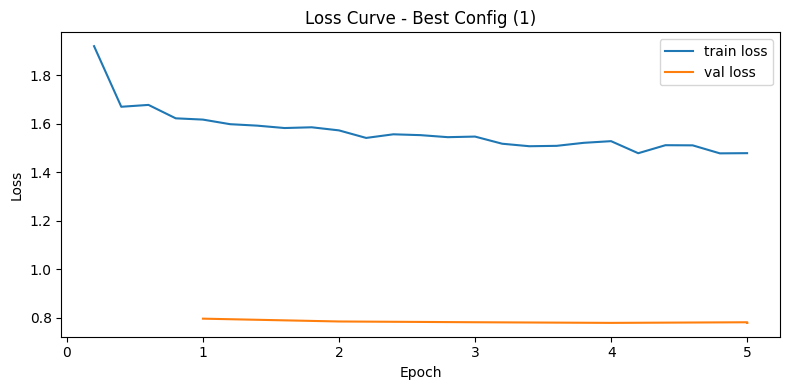

In [18]:
# loss curve for best config
import matplotlib.pyplot as plt

log_history = best_trainer.state.log_history
train_loss = [(x['epoch'], x['loss'])      for x in log_history if 'loss' in x and 'eval_loss' not in x]
val_loss   = [(x['epoch'], x['eval_loss']) for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(8, 4))
plt.plot(*zip(*train_loss), label='train loss')
plt.plot(*zip(*val_loss),   label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title(f'Loss Curve - Best Config ({best_config_idx})')
plt.tight_layout()
plt.savefig('loss_curve.png')
plt.show()

In [19]:
# summary
import pandas as pd

results_df = pd.DataFrame(results)

# append base model row for comparison
base_row = pd.DataFrame([{"config": "base", "learning_rate": "-", "num_train_epochs": "-",
                           "warmup_ratio": "-", "weight_decay": "-", "lora_r": "-",
                           "eval_accuracy": base_metrics["eval_accuracy"],
                           "eval_f1": base_metrics["eval_f1"]}])

pd.concat([base_row, results_df[["config", "learning_rate", "num_train_epochs", "warmup_ratio", "weight_decay", "lora_r", "eval_accuracy", "eval_f1"]]], ignore_index=True)

,config,learning_rate,num_train_epochs,warmup_ratio,weight_decay,lora_r,eval_accuracy,eval_f1
0,base,-,-,-,-,-,0.279628,0.122716
1,1,0.0002,5,0.1,0.01,32,0.636764,0.611721
2,2,0.0002,8,0.1,0.01,32,0.633763,0.602181
3,3,0.0002,5,0.1,0.01,64,0.631863,0.605072
4,4,0.0001,5,0.1,0.01,32,0.634863,0.608037
5,5,0.0002,5,0.1,0.05,32,0.636364,0.606901


In [20]:
# failure mode analysis
pred_output = best_trainer.predict(test_dataset)
pred_labels = np.argmax(pred_output.predictions, axis=-1)
true_labels = pred_output.label_ids

test_results_df = pd.DataFrame({
    "text":            X_test.tolist(),
    "true_label":      le.inverse_transform(true_labels),
    "predicted_label": le.inverse_transform(pred_labels),
    "correct":         pred_labels == true_labels
})

# confusion breakdown - where does it fail?
print(test_results_df.groupby(['true_label', 'predicted_label']).size().unstack(fill_value=0))

# look at failure examples
failures = test_results_df[test_results_df['correct'] == False]
print(f"\nOverall test accuracy: {test_results_df['correct'].mean():.4f}")

predicted_label    o     v     x
true_label                      
o                722  1682   390
v                498  4277   327
x                209   522  1373

Overall test accuracy: 0.6372


In [21]:
# Export failures to CSV

failures.to_csv("failure_cases.csv", index=False)

## Conclusion

No one change in hyperparameters, be it in learning rate, number of epochs, weight decay or LoRA `r` produced no improvement over the baseline.

The model produced a respectable 63.67% accuracy, scoring well in classifying truly positive or negative reviews, though it struggled with correctly classifying neutral reviews, possibly due to the ambiguity of the pros and cons in the reviews.

### Potential Extensions

The use of a fine-tuned LLM serves as a worthy starting point in predicting sentiment based on textual reviews. However, the task could greatly benefit from running classification or regression on the several other categories present in the dataset, such as job title and location, or numerical values like ratings of compensation and benefits, work-life balance, and opinion on senior management.

Other machine learning architecture like multi-layer perceptrons could potentially excel at involving these variables as predictors, and could complement LLM fine-tuning as part of a pipeline to predict Glassdoor review sentiment with greater accuracy.